In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv('breast-cancer.csv')

In [18]:
X= df.drop('diagnosis',axis=1)
y= df['diagnosis']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [35]:
dt_entropy = DecisionTreeClassifier(
    criterion = 'entropy',
    random_state = 42
)

In [36]:
dt_entropy.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
y_pred = dt_entropy.predict(X_test)

In [23]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[70  1]
 [ 4 39]]

Classification Report:
               precision    recall  f1-score   support

           B       0.95      0.99      0.97        71
           M       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Accuracy Score: 0.956140350877193


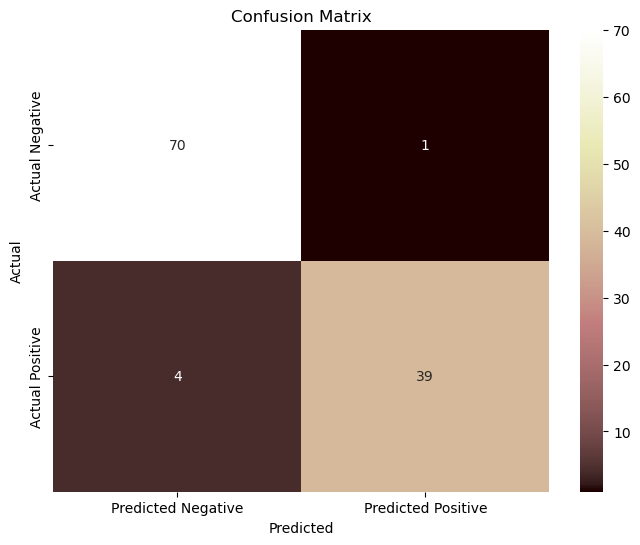

In [31]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="pink", xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

[Text(0.5595238095238095, 0.9375, 'concave points_mean <= 0.051\nentropy = 0.952\nsamples = 455\nvalue = [286, 169]\nclass = y[0]'),
 Text(0.30952380952380953, 0.8125, 'radius_worst <= 16.83\nentropy = 0.314\nsamples = 282\nvalue = [266, 16]\nclass = y[0]'),
 Text(0.43452380952380953, 0.875, 'True  '),
 Text(0.19047619047619047, 0.6875, 'area_se <= 48.7\nentropy = 0.136\nsamples = 263\nvalue = [258, 5]\nclass = y[0]'),
 Text(0.09523809523809523, 0.5625, 'texture_worst <= 30.145\nentropy = 0.091\nsamples = 260\nvalue = [257, 3]\nclass = y[0]'),
 Text(0.047619047619047616, 0.4375, 'entropy = 0.0\nsamples = 225\nvalue = [225, 0]\nclass = y[0]'),
 Text(0.14285714285714285, 0.4375, 'radius_worst <= 14.43\nentropy = 0.422\nsamples = 35\nvalue = [32, 3]\nclass = y[0]'),
 Text(0.09523809523809523, 0.3125, 'entropy = 0.0\nsamples = 25\nvalue = [25, 0]\nclass = y[0]'),
 Text(0.19047619047619047, 0.3125, 'perimeter_mean <= 86.26\nentropy = 0.881\nsamples = 10\nvalue = [7, 3]\nclass = y[0]'),
 Tex

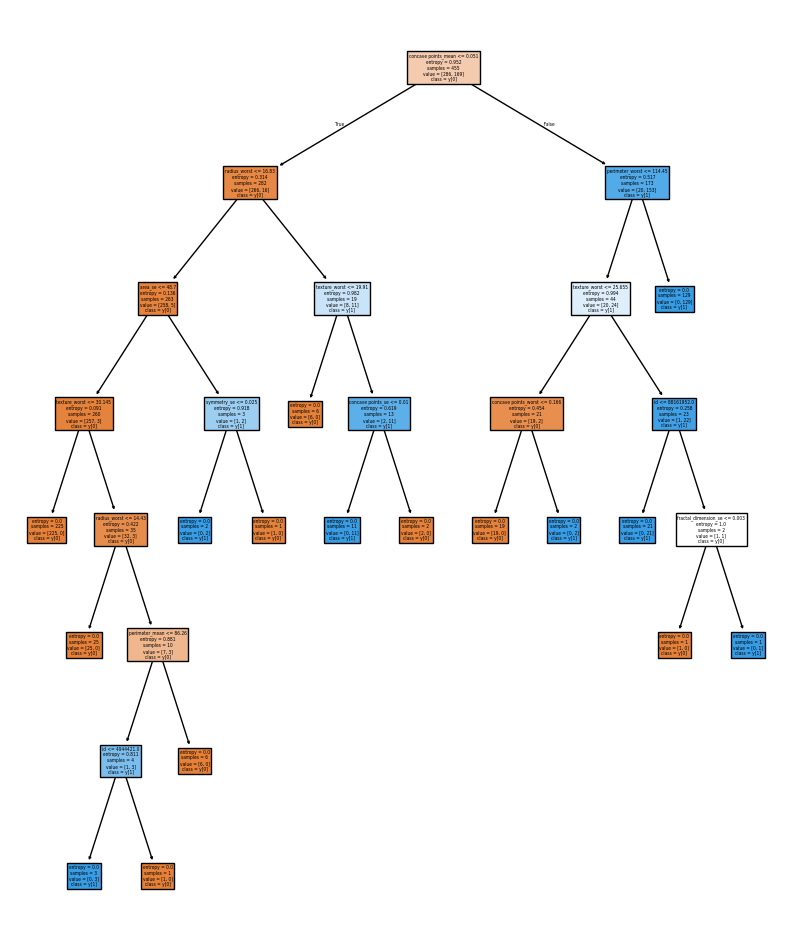

In [39]:
plt.figure(figsize=(10,12))

plot_tree(
    dt_entropy,
    filled=True,
    feature_names=X.columns,    
    class_names=True
)

In [40]:
dt_gini = DecisionTreeClassifier(
    criterion = 'gini',
    random_state = 42
)

In [41]:
dt_gini.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
y_pred = dt_gini.predict(X_test)

In [44]:
print("Accuracy :",accuracy_score(y_test,y_pred))

Accuracy : 0.9385964912280702


In [46]:
# PrePruning 

df_pre = DecisionTreeClassifier(
    criterion = 'entropy',
    max_depth =5,
    min_samples_split = 10,
    min_samples_leaf = 5,
    random_state = 42
)


In [47]:
df_pre.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [48]:
y_pred_pre = df_pre.predict(X_test)

In [49]:
print("Accuracy with Pre-Pruning:", accuracy_score(y_test, y_pred_pre))
print("Confusion Matrix with Pre-Pruning:\n", confusion_matrix(y_test, y_pred_pre))
print("\nClassification Report with Pre-Pruning:\n", classification_report(y_test, y_pred_pre))


Accuracy with Pre-Pruning: 0.9649122807017544
Confusion Matrix with Pre-Pruning:
 [[71  0]
 [ 4 39]]

Classification Report with Pre-Pruning:
               precision    recall  f1-score   support

           B       0.95      1.00      0.97        71
           M       1.00      0.91      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [50]:
# Post-Pruning
df_post = DecisionTreeClassifier(
    criterion = 'entropy',
    ccp_alpha = 0.03,
    random_state = 42
)


In [51]:
df_post.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
y_pred_post = df_post.predict(X_test)

In [56]:
print("Accuracy with Pre-Pruning:", accuracy_score(y_test, y_pred_pre))
print("Confusion Matrix with Pre-Pruning:\n", confusion_matrix(y_test, y_pred_pre))
print("\nClassification Report with Pre-Pruning:\n", classification_report(y_test, y_pred_pre))  

print("Accuracy with Post-Pruning:", accuracy_score(y_test, y_pred_post))
print("Confusion Matrix with Post-Pruning:\n", confusion_matrix(y_test, y_pred_post))
print("\nClassification Report with Post-Pruning:\n", classification_report(y_test, y_pred_post))  

Accuracy with Pre-Pruning: 0.9649122807017544
Confusion Matrix with Pre-Pruning:
 [[71  0]
 [ 4 39]]

Classification Report with Pre-Pruning:
               precision    recall  f1-score   support

           B       0.95      1.00      0.97        71
           M       1.00      0.91      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

Accuracy with Post-Pruning: 0.9649122807017544
Confusion Matrix with Post-Pruning:
 [[71  0]
 [ 4 39]]

Classification Report with Post-Pruning:
               precision    recall  f1-score   support

           B       0.95      1.00      0.97        71
           M       1.00      0.91      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

